# Example code for reading and analysis of swissfel data

## Bernina anaconda environment
### Standard regularly updated environment

If using the bernina conda activate in Terminal (you can open that in Jupytera with "New --> Terminal").
```bash
source /sf/bernina/bin/anaconda_env
```
The script includes adding Bernina environments to your .condarc file in your home folder with content
```
envs_dirs:
  - /sf/bernina/applications/bm/envs
```
it is using this command line:
```bash
conda config --add envs_dirs /sf/bernina/applications/bm/envs
```

### Cloning Bernina environment in experiment folder
It might make sense to clone the running environment in the experiment's folder in order to protect it from upgrades and changes. In that case 
``` bash
conda config --add envs_dirs /sf/bernina/data/<pgroup>/work/src
conda env create -p /sf/bernina/data/<pgroup>/work/src/<envname> -f /sf/bernina/anaconda/env_specifications/<env_spec>.yml
```



## Creating links in home folder for access to Bernina data folders
When running analysis from Juppytera which is web interface only, you can't immediately access data folders from the jupyter browser which is does not support navigating to parent folders of your home folder. 

You can create Bernina folder access by
``` bash
/sf/bernina/bin/create_data_symlinks
```
which does

``` bash
ln -s /sf/bernina/data bernina_data
ln -s /sf/bernina/exp bernina_exp
```
creating directory links 
```bernina_data``` for the raw data folders, and ```bernina_exp``` for data folders with user friendlier names, both inside your home folder.
Your'll find the notebook of this example here under:
```
bernina_exp/example_data/Bi_tt/Bernina_Bi_analysis_example.ipynb
```



## Reading data using ```escape``` parser

Importing some usual and useful tools, as well as a file parser for the scan json files:

In [1]:
%matplotlib widget
import sys
import numpy as np
import matplotlib.pyplot as plt
from escape.swissfel import parse_scan
from escape.utilities import nfigure
import escape

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/dask_jobqueue/core.py:20: FutureWarning: tmpfile is deprecated and will be removed in a future release. Please use dask.utils.tmpfile instead.
  from distributed.utils import tmpfile


Using the swissfel parser from escape to look for datasets in the hdf5 files and create h5py array links to each relevant dataset in the data. By default this infomration is output as as
```
escape.Array ,
```
an object using dask arrays as pointer to the data from all scan steps.

The ```createEscArrays``` keyword set to False allows to retrieve h5py handles instead of escape arrays. 
The memlimit_mD_MB is the "chunk size limit" for large datasets as the JF7 (16Mpix), which needs to be a bit larger than the default for one 16 Mpix image per chunk. Size of the raw 16 bit data is calculated like: 16 \* (1024\*1024) pixels * 2 byte = 32 Mbyte.

The number of files to parse can be large for scan data with many steps, it can take longer time. The underlying code uses some concurrency (python threads).

In [2]:
data = parse_scan('/sf/bernina/exp/example_data/Bi_tt/run0065_Bi111_shortdelay_scan.json')

[########################################] | 100% Completed | 13.0s


## Some examples of the escape Array properties
The following shows some main properties of ```escape.Array``` objects, more details can be seen in the examples of this document.
The Array object
- includes data and index (cf. pulse id) arrays for each pulse
- compute by including only matching indexes (overloads computation operators in python)

See the following example for how data matching works:

In [3]:
from escape import Array

a = Array(
    data=np.asarray([8,4,3,7]),
    index=np.asarray([0,1,3,4]))
b = Array(
    data=np.asarray([2,2,2,2]),
    index=np.asarray([0,1,2,4]))
c = a-b
print(c.index,c.data)


[0 1 4] [6 2 5]


The order of indexes is additionally taken into account before doing the calculation. As a most general rule, the order of the first element is used for the result: 

In [4]:
d = Array(
    data=np.asarray([8,4,3,7]),
    index=np.asarray([2,3,0,1]))
e = Array(
    data=np.asarray([2,2,2,2]),
    index=np.asarray([0,1,2,3]))
f = d-e
print(f.index,f.data)
g = -e+d
print(g.index,g.data)

[2 3 0 1] [6 2 1 5]
[0 1 2 3] [1 5 6 2]


## Correct Jungfrau data for gains and pedestals
The usually recorded raw data from Jungfrau detectors need at minimum be corrected for the dark signal (pedestal) and their sensitivity, usually in 3 different autimatically switching gain steps. While the gain (or scaling of digital units to keVs) is considered constant over time, the pedestal dark can change over time and should be accounted for by regularly repeaded "dark" measurements, so those are data set dependent.

The following block shows how to wrap a function that if can be applied on every element in the escape.Array using the underlying dask.Array mechanism for parallel optimisation. The result is then again an ```escape.Array``` which includes the computations that will applied when actually rewuesting data from it by the compute method.

In [5]:
from jungfrau_utils import JFDataHandler
# from escape import escaped

JungfrauId = 'JF04T01V01'
def correct(data,fina_gain,fina_ped,JungfrauId):
    dh = JFDataHandler(JungfrauId)
    dh.gain_file=fina_gain
    dh.pedestal_file=fina_ped
    return data.map_index_blocks(dh.process,dtype=dh.get_dtype_out(data.data.dtype),new_element_size=dh.get_shape_out())

det_diff = correct(
    data['JF04T01V01'],
    '/sf/bernina/config/jungfrau/gainMaps/JF04T01V01/gains.h5',
    '/sf/bernina/exp/example_data/Bi_tt/pedestal_20190226_2049.JF04T01V01.res.h5',
    'JF04T01V01',
)
  
det_i0 = correct(
    data['JF03T01V01'],
    '/sf/bernina/config/jungfrau/gainMaps/JF03T01V01/gains.h5',
    '/sf/bernina/exp/example_data/Bi_tt/pedestal_20190226_2049.JF03T01V01.res.h5',
    'JF03T01V01',
)

## Visualisation: Jungfrau area detector signals at low and medium photon count per pixel
The example data consist of two single tile JF detectors, one of which collects mainly elastic scatter from a Kapton foil and Air used as I_0 (jf3) and one measuring the Bragg peak from the 111 reflection of a ~50 nm Bi film (jf4).

jf3 is in the few photon per pixel intensity level, while in the Bi Bragg peak 10s of photons per pixel and pulse are measured. The data after pedestal gain correction shows the absorbed X-ray signal scaled to eV, therefore single photons of the elastically scattered 9 keV FEL energy show up at values of 9, and will show up as multples where multiple photons have been absobed per pixel. Intensity between those "photon peaks" that show up in the histogram of pixels originate from charge sharing where the Xray-induced charge cloud in the Si sensor material gets read into different pixels.

The following shows those data as the raw pattern and a histogram of the data within for the two detectors. For the last plot row the Bi peak data was reduced to a region of interest. All data come from a single (the first available) X-ray pulse, which is read and corrected directly from the dask array by its compute method.

The jf3 detector has a bad quadrant appearing dark in the image.

### A word about matplotlib plotting in Jupyterlab
Most users might find it most favourable to create interactive matplotlib plots which allow changing axes zooming and other things using a mouse. The interactive features are bit difficult to obtain for the different types of jupyter. In the case of jupyterlab we have best experience using
```
%matplotlib widget
```
at the begin of notebooks which requires installation of the ipympl package. 
In order to create plots from a cell that recreate on a second call of that cell, the best way is presently to prophilactically close the figure before opening like
```
plt.close(<figname>)
plt.figure(<figname>)
```
or 
```
plt.close(<figname>)
plt.subplots(... , num=<figname>, ...)
```

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/numba/np/arraymath.py:3845: DeprecationWarning: `np.MachAr` is deprecated (NumPy 1.22).
  @overload(np.MachAr)
/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:477: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super(Widget, self).__init__(**kwargs)


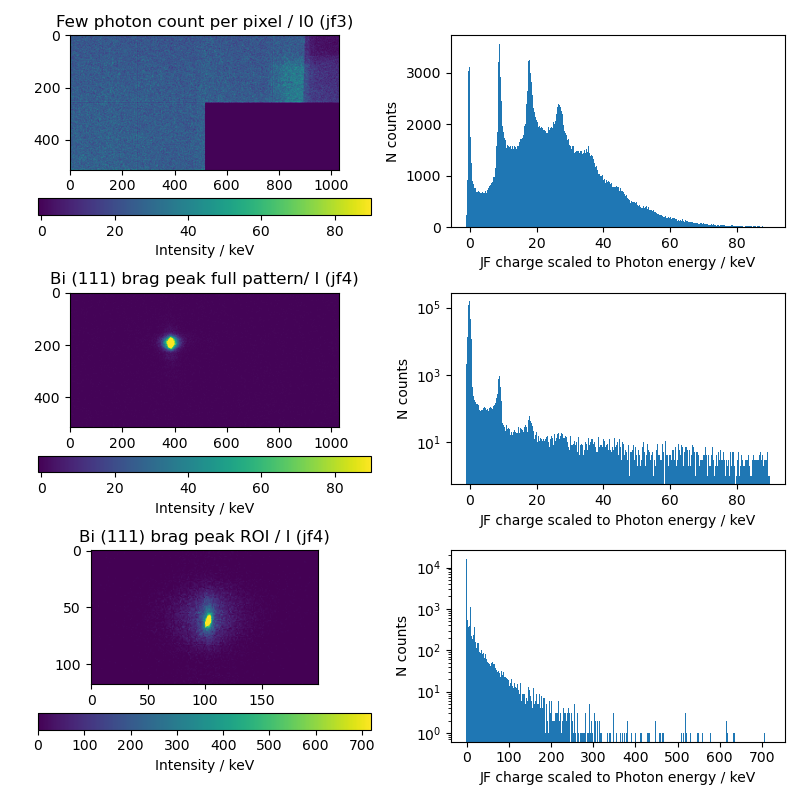

In [6]:
# Showing some properties of the Jungfrau data
photon_energy = 9 # keV
plot_max = 10
energy_resolution = .2

pattern = det_i0.data[0].compute()
plt.close('JF detector signals')
fig,axs = plt.subplots(3,2,num='JF detector signals',figsize=[8,8])
im = axs[0,0].imshow(pattern,clim=[-1,photon_energy*plot_max])
fig.colorbar(im,ax=axs[0,0],orientation='horizontal').ax.set_xlabel('Intensity / keV')
axs[0,0].set_title("Few photon count per pixel / I0 (jf3)")
dum = axs[0,1].hist(pattern[pattern.nonzero()].ravel(),np.arange(-1,plot_max*photon_energy,energy_resolution))
axs[0,1].set_xlabel('JF charge scaled to Photon energy / keV')
axs[0,1].set_ylabel('N counts')

pattern = det_diff.data[0].compute()
im = axs[1,0].imshow(pattern,clim=[-1,photon_energy*plot_max])
fig.colorbar(im,ax=axs[1,0],orientation='horizontal').ax.set_xlabel('Intensity / keV')
axs[1,0].set_title("Bi (111) brag peak full pattern/ I (jf4)")
dum = axs[1,1].hist(pattern[pattern.nonzero()].ravel(),np.arange(-1,plot_max*photon_energy,energy_resolution))
axs[1,1].set_xlabel('JF charge scaled to Photon energy / keV')
axs[1,1].set_ylabel('N counts')
axs[1,1].set_yscale('log')

#looking at ROI
plot_max = 80
energy_resolution = 2
pattern = pattern[134:252, 282:482]
im = axs[2,0].imshow(pattern,clim=[-1,photon_energy*plot_max])
axs[2,0].set_title("Bi (111) brag peak ROI / I (jf4)")
fig.colorbar(im,ax=axs[2,0],orientation='horizontal').ax.set_xlabel('Intensity / keV')
dum = axs[2,1].hist(pattern[pattern.nonzero()].ravel(),np.arange(-1,plot_max*photon_energy,energy_resolution))
axs[2,1].set_xlabel('JF charge scaled to Photon energy / keV')
axs[2,1].set_ylabel('N counts')
axs[2,1].set_yscale('log')

plt.tight_layout()

## Noise (zero photon) peak threashold and reducing and summing region of interest

Especially at low photon counts a lot of pixels have measured zero photons and form a zero photon peak whose width represents the intrinsitc noise level of the detector. At low count rates this noise can dominate an integrated signal from multiple pixels, but can be reduced by disregarding the zero photon peak data. This is typically accomplished by setting a thrreshold between zero and first photon peak, done right in the center in the following example. Data below that threshold (at 4.5 keV) are marked masked by setting them to ```np.nan``` for later disregarding. In order to apply this masking again a short function was written and then applied on the ```escape.Array``` by the ```map_even_blocks``` method.

The data is then integrated by just applying a sum (using nansum which disregards the ```np.nan``` values inserted as a mask). This can be directly done on the ```escape.Array```.

In [7]:
def threshold_data(d,threshold,fill = np.nan):
    d[d<threshold] = fill
    return d

threshold = 4.5 # keV
i0_thres = det_i0.map_index_blocks(threshold_data,threshold)
i_thres = det_diff.map_index_blocks(threshold_data,threshold)

i0 = i0_thres[:,:512,:512].nansum(axis=(1,2))/photon_energy
i = i_thres[:,134:252, 282:482].nansum(axis=(1,2))/photon_energy

## Timing tool data
In the example scan shown here, the timing tool was a spectral time tool, where a microscope image of a thin target membrane is totally illuminated by the ultrafast 800 nm pulse, and X-rays induce a reduction of transmissiondata in the membrane. By a tilted geometry the horizontal (longer) axis of the camera image 2D arrays becomes temporally dipersive and the arrival time of the X-ray FEL pulse with respect to the probing 800nm pulse shows up as a step in horizontal direction. 

The following shows how one can generate very simple projections of the raw 2D data that show the X-ray induced effect as a step.

The projections are below plotted, labelled with their SwissFEL pulse_id, which is carried by each ```escape.Array``` as an index in the ```index dataset```. This index field is not a dask array but is a numpy array.

The projections show few pulse_ids without a step visible in the data which are purposely taken "off-shots" or references, that are taken with the laser pulse delayed with respect to the FEL pulse, so that no pump signal appears. 

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:477: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super(Widget, self).__init__(**kwargs)


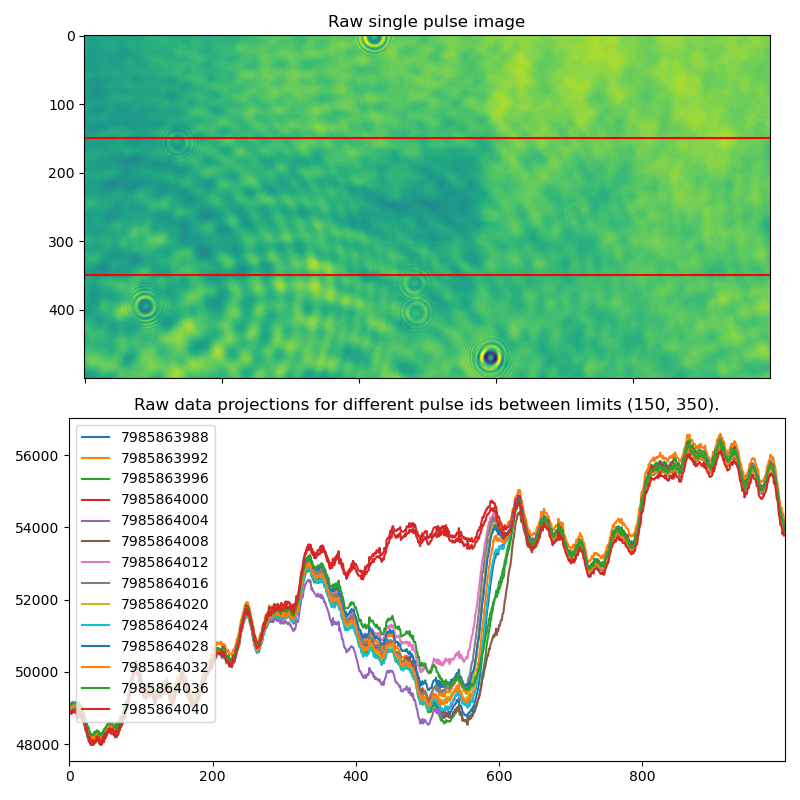

In [8]:
# vertical integration region
int_limits = (150,350)

# timetool raw data
tt_img = data['SARES20-PROF142-M3:FPICTURE']

# take projections
tt_proj = tt_img[:,slice(*int_limits),:].mean(axis=1)

# calculate and visualize some data
ndat = 14
projdat = tt_proj.data[:ndat].compute() 
ixs = tt_proj.index[:ndat]

plt.close('Timetool projection')
fig,axs = plt.subplots(2,1,num='Timetool projection',sharex=True,figsize=[8,8])
axs[0].imshow(tt_img.data[0])
for int_limit in int_limits:
    axs[0].axhline(int_limit,color='r')
axs[0].set_title('Raw single pulse image')

for ix,proj in zip(ixs,projdat):
    axs[1].plot(proj,label=f"{ix:d}")
plt.legend()
axs[1].set_title(f'Raw data projections for different pulse ids between limits {int_limits}.')

axs[0].get_shared_x_axes().join(*axs)
plt.tight_layout()

## Reference data selection and calculations for timing tool
The time tool projection reference data shown above are to be separated from the FEL pumped data set. For this the infromation about the reference case is determined from a dataset with 256 booleans (the set of event codes) that represent different conditions the SwissFEL timing system generated triggers from. The trigger used for the mentioned timing delay for the references is number 25. The data some in integers and are converted to booleans, which is understood better by escape Arrays for data downselection in brackets. The python inversion symbol ```~``` negates the boolean array.

The calulation of the reference we do here per scan step. The datasets of individual scan steps can be obtained in the object ```scan```.

In [9]:
evt_set = data['SAR-CVME-TIFALL5:EvtSet']
laser_delayed = evt_set[:,25]==1

tt_proj_delayed = tt_proj[laser_delayed]
tt_proj_xpumped = tt_proj[~laser_delayed]

print('Shape of timetool projection dataset, first step only')
print(f'All data {tt_proj.scan[0].shape}')
print(f'reference data {tt_proj_delayed.scan[0].shape}')
print(f'FEL pumped data {tt_proj_xpumped.scan[0].shape}')

Shape of timetool projection dataset, first step only
All data (500, 1000)
reference data (50, 1000)
FEL pumped data (450, 1000)


We can rebin the array into bins of index number ranges, in order to average references and for the data independently of the actual scan steps taken during acquisition.

In [10]:
rebin = tt_proj.get_index_array(N_index_aggregation=5000)

This escape.Array data contains now the index (aka pulse id) as data _and_ index, and it is sorted into groups spanning at most 1000 index numbers:

In [11]:
print(rebin.scan[0].data[:5])
print(rebin.scan[0].index[:5])

[7985863988 7985863992 7985863996 7985864000 7985864004]
[7985863988 7985863992 7985863996 7985864000 7985864004]


The new grouping, i.e. the ordering of pulse data and the groups, can be applied on other data in different ways. Please note that this is the opposite of the example above to select the delayed and pumped pulse where the order is not changed. 

The array has a method categorizing another array only by the index groups, the other array will keep the data. Another option is to use an escape operation which happens with most computational or logical operators between two escape arrays. When creating an array from another where all data is replaces by unity, it may be multiplied with another array which then will inherit the sorting from the first array within the operation. This convention is attempted to keep in all places in escape, the first array in an operation or even in syntax is doninant in terms of sorting and grouping of the puse data.
```
rebin.categorize(tt_proj_xpumped)
```
is equal to 
```
rebin.ones()[:,None]*tt_proj_xpumped
```

For calculating spectra differences, we take all references from each new bin, average it, and divide the data by that average per bin. 

In order to run over scan step  there is the ```escape.Array.scan``` object which allows to iterate over groups of data (_e.g._ scan steps), and has some methods defined that run over all scan steps (as here ```mean```), returning a list of the means. 

Each scan step of the non reference data we divide by those means. The scan object will calculate a pre step calculation, when an operation is asked for between a list with same number of elements as steps in the scan.

In [12]:
tt_proj_corr = rebin.categorize(tt_proj_xpumped).scan / rebin.categorize(tt_proj_delayed).scan.mean(axis=0)

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:477: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super(Widget, self).__init__(**kwargs)


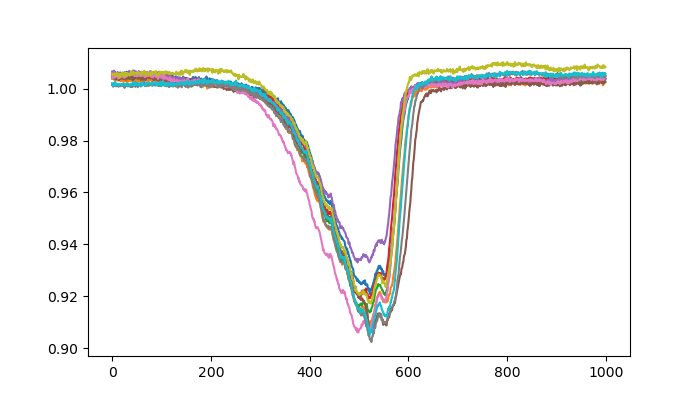

In [13]:
plt.close('Time tool results')
fig,axs = plt.subplots(1,1,num='Time tool results',figsize=[7,4])
axs.plot(tt_proj_corr[:10][::-1].data.T);

The corrected profiles are now in a form which can be analyzed for the step location. This is again done with the ```map_index_blocks``` method.

In [14]:
from escape.swissfel import timetool
refstep = timetool.get_reference_function(width_px=30,reflen=150)

posamp = tt_proj_corr[:,::-1].map_index_blocks(lambda d: np.asarray([timetool.find_signal(td,refstep) for td in d]),new_element_size=(2,),dtype=float)
tt_pos = posamp[:,0]
tt_amp = posamp[:,1]

# tt_pos,tt_amp = escape.storage.compute(tt_pos,tt_amp)

Visualisation of timing tool projections and found step locations:

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:477: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super(Widget, self).__init__(**kwargs)


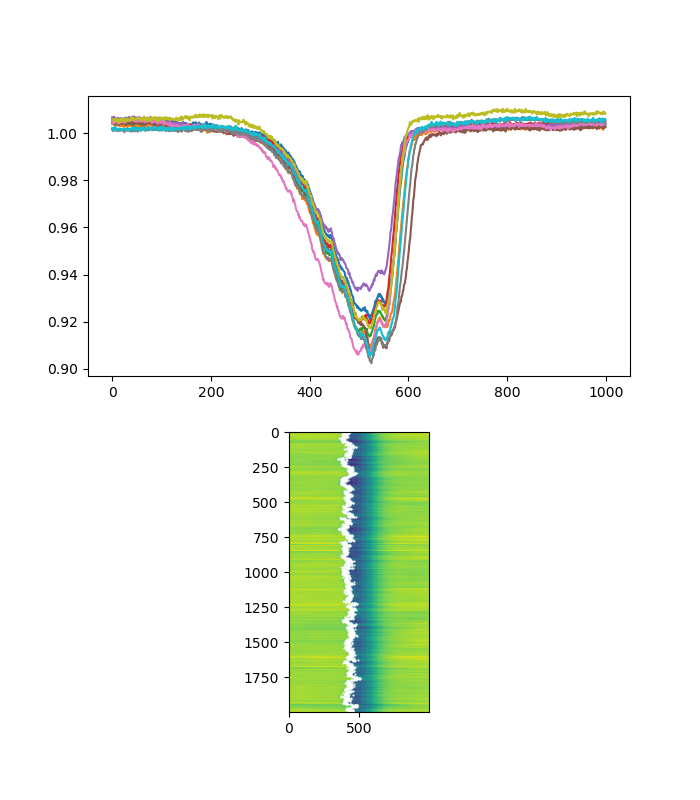

In [15]:
plt.close('Time tool results')
fig,axs = plt.subplots(2,1,num='Time tool results',figsize=[7,8])
for ax in axs:
    ax.cla()
axs[0].plot(tt_proj_corr[:10][::-1].data.T)
axs[1].imshow(tt_proj_corr[:2000][:,::-1].data)
axs[1].plot(tt_pos[:2000].data,np.arange(2000),'w.',ms=1)

# Data computation and storage 

The prepared objects and escape variables contain only lazy exexution manuals and have only analyzed data from few pulses yet for visualisation. It is therefore easy to develop the analysis and debug on the same code which is eventually used for full computation. 

As a full reduction would take a while it would be great not to have to redo the reduction lateron. For this escape arrays have the ```store``` method which writes the results as escape arrays to an hdf5 array. The hdf5 location is defined by a h5py file or group object handle.

We assign all relevant data to variable names and store in the following all relevant data with user-friendlier names to a file in your home folder.

Depending on resources the data reduction can take enough time for a coffee, on a shared ra partition it took about 20 mins.

In [16]:
import h5py
from pathlib import Path

evt_set = data['SAR-CVME-TIFALL5:EvtSet']
mon_opt_i = data['SLAAR21-LTIM01-EVR0:CALCI']
mon_opt_x = data['SLAAR21-LTIM01-EVR0:CALCX']
mon_opt_y = data['SLAAR21-LTIM01-EVR0:CALCY']

file_name = Path('~/Bi_tt_example_data_reduced.h5').expanduser()

# delete result file in case it got corrupted or for demonstration
# file_name.unlink() 
fh = h5py.File(file_name,'w')

print('Storage of event set (from file to file)')
evt_set.store(fh,'evt_set')
print('Storage of one-dimensional data (from file to file)')
%time mon_opt_i.store(fh,'mon_opt_i')
%time mon_opt_x.store(fh,'mon_opt_x')
%time mon_opt_y.store(fh,'mon_opt_y')

laser_delayed = evt_set[:,25]==1

print('Reading of 2 x 0.5 Mpix Jungfrau data, gain and pedestal correction, region of interest, summming up, and saving')
%time i0.store(fh,'i0')
%time i.store(fh,'i')

print('Reading of timetool data, proijection and saving')
%time tt_proj.store(fh,'tt_proj')

print('Reading of projected timetool data, correcting and saving')
%time tt_proj_corr.store(fh,'tt_proj_corr')

print('Reading of corrected projected timetool data, edge finding and saving')
%time tt_pos.store(fh,'tt_pos')

fh.close()

Storage of event set (from file to file)
[########################################] | 100% Completed |  0.4s
Storage of one-dimensional data (from file to file)
[########################################] | 100% Completed |  0.4s
[########################################] | 100% Completed |  0.4s
CPU times: user 652 ms, sys: 204 ms, total: 856 ms
Wall time: 941 ms
[########################################] | 100% Completed |  0.3s
[########################################] | 100% Completed |  0.4s
CPU times: user 648 ms, sys: 165 ms, total: 813 ms
Wall time: 871 ms
[########################################] | 100% Completed |  0.4s
[########################################] | 100% Completed |  0.4s
CPU times: user 704 ms, sys: 197 ms, total: 900 ms
Wall time: 951 ms
Reading of 2 x 0.5 Mpix Jungfrau data, gain and pedestal correction, region of interest, summming up, and saving
[########################################] | 100% Completed |  6min 31.7s
CPU times: user 6min 59s, sys: 1min 1

# Calculation with computed small data

The following loads data that have been saved in the previous section and can be run independentlyfrom the next code cell on.

In [17]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


import h5py
from escape import Array,broadcast_to,digitize,match_arrays, concatenate
from escape.utilities import nfigure

# fh = h5py.File(Path('~/Bi_tt_example_data_reduced.h5').expanduser(),'r')

# Preanalyzed example
fh = h5py.File(Path('/sf/bernina/exp/example_data/Bi_tt/Bi_tt_example_data_reduced.h5').expanduser(),'r')
print(list(fh.keys()))
tt_proj = Array.load_from_h5(fh,'tt_proj')
evt_set = Array.load_from_h5(fh,'evt_set')
i = Array.load_from_h5(fh,'i')
i0 = Array.load_from_h5(fh,'i0')
tt_pos = Array.load_from_h5(fh,'tt_pos')
laser_delayed = evt_set[:,25]==1


['evt_set', 'i', 'i0', 'mon_opt_i', 'mon_opt_x', 'mon_opt_y', 'tt_pos', 'tt_proj', 'tt_proj_corr']


/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/h5py/_hl/dataset.py:541: DeprecationWarning: Passing None into shape arguments as an alias for () is deprecated.
  arr = numpy.ndarray(selection.mshape, dtype=new_dtype)


## Computation of calibrated and time tool corrected timing data
The time setpoint array of the scan can be determined from the (pandas) table of the scan subobject:

In [18]:
t_scan = (i.categorize(tt_pos).scan.par_steps).iloc[:,0]

The timing tool data is calibrated according to an offset of 600 and a gain value of -2.25 fs per pixel:

In [19]:
tt_pos_s = (tt_pos-600)*-2.25e-15

Scan objects can be added to arrays of the same length element-wise. For this the tt_pos_s needs to be resorted to the old format of the scan, which can e.g. be inherited from the Bragg intensity:

In [20]:
t = i.categorize(tt_pos_s).scan + t_scan

The new time escape array t can be binned using the digitize method. This only works after computing the data:

In [21]:
t_sorted = t.compute().digitize(np.arange(np.min(t_scan),np.max(t_scan),10e-15))

[########################################] | 100% Completed |  1.6s


Calculate nomralized signal, correct for drift, and for jitter.

In [22]:
i_norm = (i/i0.compute().filter(6e5,16e5)).compute()

i_norm_driftcorr = i_norm[~laser_delayed].scan / i_norm[laser_delayed].scan.mean()

i_norm_driftjittercorr = t_sorted.categorize(i_norm_driftcorr)

[########################################] | 100% Completed |  0.6s
[########################################] | 100% Completed |  1.5s


## Visualisation: Pump/probe result fully corrected

/sf/bernina/applications/bm/envs/bernina38/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:477: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super(Widget, self).__init__(**kwargs)


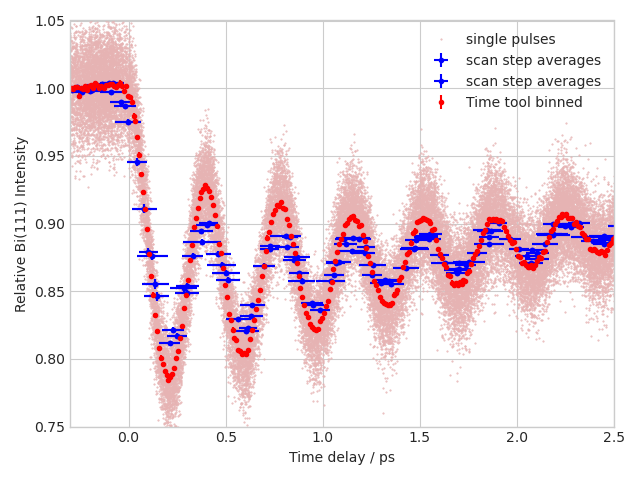

In [23]:
from matplotlib import style
style.use('seaborn-whitegrid')
plt.close('TR plot')
f,ax = plt.subplots(num='TR plot')

t0 = 1.2044e-9

mn = [np.nanmean(tr.data) for tr in (i_norm_driftjittercorr).scan]
er = [np.nanstd(tr.data)/sum(~np.isnan(tr.data))**.5 for tr in (i_norm_driftjittercorr).scan]

mn0 = [np.nanmean(tr.data) for tr in (t.ones()*i_norm_driftcorr).scan]
er0 = [np.nanstd(tr.data)/sum(~np.isnan(tr.data))**.5 for tr in (t.ones()*i_norm_driftcorr).scan]

x0 = [np.nanmean(tr.data) for tr in t.scan]
er0x = [np.nanstd(tr.data) for tr in t.scan]

rat,ttot = match_arrays(i_norm_driftjittercorr,t_sorted)
parname = list(i_norm.scan.parameter.keys())[0]

ax.plot(1e12*(ttot.data-t0),rat.data,'.',ms=1,label='single pulses',color=[.9,.7,.7] )
ax.errorbar(1e12*(np.asarray(x0)-t0),mn0,yerr=er0,xerr=1e12*np.asarray(er0x),fmt='b.',label='scan step averages')
ax.errorbar(1e12*(np.asarray(x0)-t0),mn0,yerr=er0,xerr=1e12*np.asarray(er0x),fmt='b.',label='scan step averages')
parname = list(i_norm_driftjittercorr.scan.parameter.keys())[0]
ax.errorbar(1e12*(np.asarray((i_norm_driftjittercorr).scan.par_steps.iloc[:,0])-t0),mn,yerr=er,fmt='.r',label='Time tool binned')

plt.legend()
plt.axis([-.3,2.5,.75,1.05])
plt.grid('on')

plt.xlabel("Time delay / ps")
plt.ylabel("Relative Bi(111) Intensity")
plt.tight_layout()